# Tiger-Pose — 가장 쉬움, 자동 다운로드, 세팅 거의 없음, 학습 흐름 익히기용
# Animal-Pose — 개·고양이 포함, 중간 규모
# AP-10K — 본격적, 종 다양, 비상업용




In [2]:
#욜로 v8pos에서 제공하는 데이터셋 확인
import ultralytics
import os
import glob
from pathlib import Path
from ultralytics import YOLO, settings


DATASETS_DIR = Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/datasets")
RUNS_DIR = Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/runs")

DATASETS_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

settings.update({
    "datasets_dir": str(DATASETS_DIR),
    "runs_dir": str(RUNS_DIR),
})

print("datasets_dir:", settings["datasets_dir"])
print("runs_dir:", settings["runs_dir"])

# ultralytics 설치 경로
base = os.path.dirname(ultralytics.__file__)

# 1. Pose 모델 config (.yaml) - cfg/models/v8
pose_model_yamls = glob.glob(os.path.join(base, "cfg/models/**/*pose*.yaml"), recursive=True)

# 2. Pose 데이터셋 config (.yaml) - cfg/datasets
pose_data_yamls = glob.glob(os.path.join(base, "cfg/datasets/*pose*.yaml"), recursive=True)
pose_data_yamls += glob.glob(os.path.join(base, "cfg/datasets/coco*.yaml"))

print("=== Pose 모델 YAML ===")
for f in sorted(pose_model_yamls):
    print(os.path.relpath(f, base))

print("\n=== Pose 데이터셋 YAML ===")
for f in sorted(pose_data_yamls):
    print(os.path.relpath(f, base))

datasets_dir: /mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/datasets
runs_dir: /mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/runs
=== Pose 모델 YAML ===
cfg/models/11/yolo11-pose.yaml
cfg/models/12/yolo12-pose.yaml
cfg/models/26/yolo26-pose.yaml
cfg/models/v8/yolov8-pose-p6.yaml
cfg/models/v8/yolov8-pose.yaml

=== Pose 데이터셋 YAML ===
cfg/datasets/coco-pose.yaml
cfg/datasets/coco-pose.yaml
cfg/datasets/coco.yaml
cfg/datasets/coco12-formats.yaml
cfg/datasets/coco128-seg.yaml
cfg/datasets/coco128.yaml
cfg/datasets/coco8-grayscale.yaml
cfg/datasets/coco8-multispectral.yaml
cfg/datasets/coco8-pose.yaml
cfg/datasets/coco8-pose.yaml
cfg/datasets/coco8-seg.yaml
cfg/datasets/coco8.yaml
cfg/datasets/dog-pose.yaml
cfg/datasets/tiger-pose.yaml


#[2] dog-pose.yaml
- 정상적인 단일 클래스(강아지) 포즈 추정용 데이터셋이고, 키포인트가 COCO 사람(17개)보다 많은 24개로 정의되어 있음
- dog-pose는 개의 자세 추정(pose estimation) 을 위한 데이터셋으로 즉 단순히 "강아지가 어디 있나"(box)만이 아니라, 
- 강아지 몸의 관절·주요 지점 위치(키포인트)까지 라벨링되어 있습니다.

구성

클래스: 1개 (dog)
키포인트: 24개 — 코, 눈, 귀, 다리 관절, 꼬리 등 강아지 몸의 주요 지점
용도: 강아지의 자세/동작을 인식하는 모델 학습
- 데이터셋 구조

    - path: dog-pose — 데이터셋 루트 (datasets/dog-pose에 다운로드, 약 337MB)
    - train: images/train — 6,773장
    - val: images/val — 1,703장
    - test 세트 없음

- 키포인트
    - kpt_shape: [24, 3] — 키포인트 24개, 각 3차원(x, y, visible)

- 클래스
    - names: {0: dog} — 단일 클래스

기타
    - kpt_names — 클래스별 키포인트 이름 정의 (24개)
    -download — 미존재 시 ultralytics assets에서 zip 자동 다운로드


In [3]:
# 설명
import ultralytics, os

base = os.path.dirname(ultralytics.__file__)
path = os.path.join(base, "cfg/datasets/dog-pose.yaml")

with open(path, "r", encoding="utf-8") as f:
    print(f.read())

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Dogs dataset http://vision.stanford.edu/aditya86/ImageNetDogs/ by Stanford
# Documentation: https://docs.ultralytics.com/datasets/pose/dog-pose
# Example usage: yolo train data=dog-pose.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── dog-pose ← downloads here (337 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: dog-pose # dataset root dir
train: images/train # train images (relative to 'path') 6773 images
val: images/val # val images (relative to 'path') 1703 images

# Keypoints
kpt_shape: [24, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)

# Classes
names:
  0: dog

# Keypoint names per class
kpt_names:
  0:
    - front_left_paw
    - front_left_knee
    - front_left_elbow
    - rear_left_paw
    - rear_left_knee
    - rear_left_elbow
    - front_right_paw
    - front_right_knee
    - front_right_

# [샘플자료 시각화]

In [4]:
from ultralytics import YOLO
from ultralytics.utils.downloads import download
import yaml, os, glob, cv2
import matplotlib.pyplot as plt

# 1) 데이터셋 다운로드 (없으면)
if not os.path.exists("datasets/dog-pose"):
    download("https://github.com/ultralytics/assets/releases/download/v0.0.0/dog-pose.zip",
             dir="datasets/")

# 2) YAML 로드
import ultralytics
yaml_path = os.path.join(os.path.dirname(ultralytics.__file__),
                         "cfg/datasets/dog-pose.yaml")
with open(yaml_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
print("names:", cfg["names"])
print("kpt_shape:", cfg["kpt_shape"])

names: {0: 'dog'}
kpt_shape: [24, 3]


## YOLO Pose 주요 문서 링크

| 문서 | 내용 | URL |
|------|------|-----|
| Pose Estimation Datasets | 라벨 형식 정의 (2D / visibility) | https://docs.ultralytics.com/datasets/pose/ |
| Pose Estimation (Task) | 추론·학습·결과 접근법 | https://docs.ultralytics.com/tasks/pose/ |
| COCO8-Pose | yaml 예시 (`kpt_shape`, `flip_idx`, `kpt_names`) | https://docs.ultralytics.com/datasets/pose/coco8-pose/ |
| Dog-Pose | dog-pose 데이터셋 설명 | https://docs.ultralytics.com/datasets/pose/dog-pose/ |

In [5]:
# 3) 이미지 + 라벨 한 장 시각화
img_dir   = "datasets/dog-pose/images/train"
label_dir = "datasets/dog-pose/labels/train"

img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))[:1]  # 4장만
img_files

['datasets/dog-pose/images/train/n02085620_10074.jpg']

(500, 333, 3)


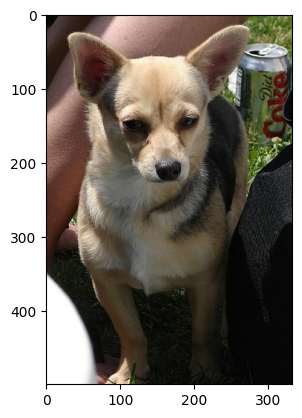

In [6]:
%matplotlib inline 
img = cv2.imread(img_files[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img)
plt.show()

In [7]:
# 3) 이미지한장 샘플출력 이미지파일.txt 라벨값 보기
img_dir   = "datasets/dog-pose/images/train"
label_dir = "datasets/dog-pose/labels/train"

img_files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))[:1]
img_path = img_files[0]

# 파일명만 떼서 → 확장자 .txt로 바꿔 → 라벨 폴더에 조인
fname = os.path.basename(img_path)              # n02085620_10074.jpg
label_name = fname.replace(".jpg", ".txt")      # n02085620_10074.txt
label_path = os.path.join(label_dir, label_name)

print("이미지:", img_path)
print("라벨 :", label_path)

# 라벨 내용 출력
print('='*100)
with open(label_path) as f:
    label_txt=f.read()
    print(label_txt)

이미지: datasets/dog-pose/images/train/n02085620_10074.jpg
라벨 : datasets/dog-pose/labels/train/n02085620_10074.txt
0 0.45195 0.508 0.75375 0.976 0.6952 0.965 2.0 0.66066 0.824 2.0 0.66817 0.677 2.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.28529 0.974 2.0 0.37087 0.861 2.0 0.22823 0.678 2.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.61461 0.12067 2.0 0.2958 0.119 2.0 0.49449 0.4 2.0 0.0 0.0 0.0 0.79878 0.04678 2.0 0.1137 0.0682 2.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0


# YOLO dog-pose 라벨 구조 분석

## 라벨 형식

Ultralytics YOLO `dog-pose.yaml` 데이터셋은 **24개 키포인트**를 사용한다.

라벨 한 줄의 구조:
- class  x_center y_center w h  (px1 py1 v1) (px2 py2 v2) ... (px24 py24 v24)

https://github.com/benjiebob/StanfordExtra/raw/master/keypoint_definitions.csv

# dog-pose 키포인트 위치값 (24개)

- 총 값 개수: `5 + 24×3 = 77`
- `v` (visibility): `0` = 미검출, `1` = 가림, `2` = 보임

## bbox 정보

| 항목 | class | x_center | y_center | width | height |
|------|-------|----------|----------|-------|--------|
| 값 | 0 | 0.45195 | 0.508 | 0.75375 | 0.976 |

라벨 구조: `class + bbox(4) + 키포인트 24×(px, py, v)`

| # | 키포인트(부위) | px | py | v | 상태 |
|----|----------------|---------|---------|---|--------|
| 1 | L_F_Paw (왼앞발) | 0.6952 | 0.965 | 2 | 검출 |
| 2 | L_F_Knee (왼앞무릎) | 0.66066 | 0.824 | 2 | 검출 |
| 3 | L_F_Elbow (왼앞팔꿈치) | 0.66817 | 0.677 | 2 | 검출 |
| 4 | L_R_Paw (왼뒷발) | 0.0 | 0.0 | 0 | 미검출 |
| 5 | L_R_Knee (왼뒤무릎) | 0.0 | 0.0 | 0 | 미검출 |
| 6 | L_R_Elbow (왼뒤팔꿈치) | 0.0 | 0.0 | 0 | 미검출 |
| 7 | R_F_Paw (오른앞발) | 0.28529 | 0.974 | 2 | 검출 |
| 8 | R_F_Knee (오른앞무릎) | 0.37087 | 0.861 | 2 | 검출 |
| 9 | R_F_Elbow (오른앞팔꿈치) | 0.22823 | 0.678 | 2 | 검출 |
| 10 | R_R_Paw (오른뒷발) | 0.0 | 0.0 | 0 | 미검출 |
| 11 | R_R_Knee (오른뒤무릎) | 0.0 | 0.0 | 0 | 미검출 |
| 12 | R_R_Elbow (오른뒤팔꿈치) | 0.0 | 0.0 | 0 | 미검출 |
| 13 | Tail_Start (꼬리밑동) | 0.0 | 0.0 | 0 | 미검출 |
| 14 | Tail_End (꼬리끝) | 0.0 | 0.0 | 0 | 미검출 |
| 15 | L_Ear_Base (왼귀밑동) | 0.61461 | 0.12067 | 2 | 검출 |
| 16 | R_Ear_Base (오른귀밑동) | 0.2958 | 0.119 | 2 | 검출 |
| 17 | Nose (코) | 0.49449 | 0.4 | 2 | 검출 |
| 18 | Chin (턱) | 0.0 | 0.0 | 0 | 미검출 |
| 19 | L_Ear_Tip (왼귀끝) | 0.79878 | 0.04678 | 2 | 검출 |
| 20 | R_Ear_Tip (오른귀끝) | 0.1137 | 0.0682 | 2 | 검출 |
| 21 | L_Eye (왼눈) | 0.0 | 0.0 | 0 | 미검출(항상0) |
| 22 | R_Eye (오른눈) | 0.0 | 0.0 | 0 | 미검출(항상0) |
| 23 | Throat (목구멍) | 0.0 | 0.0 | 0 | 미검출(항상0) |
| 24 | Withers (어깨등성이) | 0.0 | 0.0 | 0 | 미검출(항상0) |

- 검출(v=2): 11개
- 미검출(v=0): 13개 (이 중 21~24번은 데이터셋 구조상 항상 0)
- bbox: `class=0, xc=0.45195, yc=0.508, w=0.75375, h=0.976`

# [box그리기]

In [8]:
points=label_txt.split(" ")
points

['0',
 '0.45195',
 '0.508',
 '0.75375',
 '0.976',
 '0.6952',
 '0.965',
 '2.0',
 '0.66066',
 '0.824',
 '2.0',
 '0.66817',
 '0.677',
 '2.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.28529',
 '0.974',
 '2.0',
 '0.37087',
 '0.861',
 '2.0',
 '0.22823',
 '0.678',
 '2.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.61461',
 '0.12067',
 '2.0',
 '0.2958',
 '0.119',
 '2.0',
 '0.49449',
 '0.4',
 '2.0',
 '0.0',
 '0.0',
 '0.0',
 '0.79878',
 '0.04678',
 '2.0',
 '0.1137',
 '0.0682',
 '2.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0',
 '0.0']

In [9]:
bboxs=points[1:5]
bboxs


['0.45195', '0.508', '0.75375', '0.976']

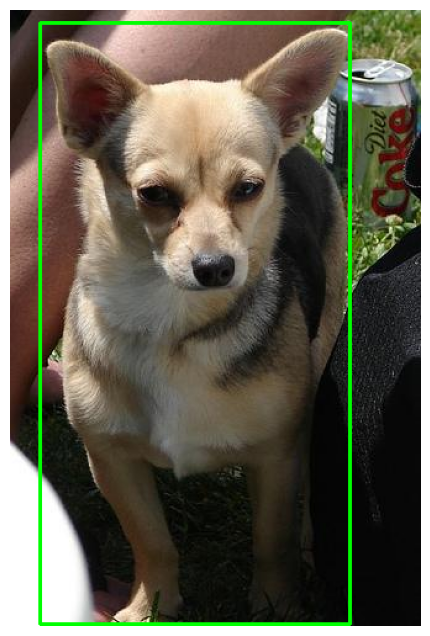

In [10]:
H, W = img.shape[:2]

# bboxs 문자열 -> float
xc, yc, bw, bh = map(float, bboxs)

# 정규화 -> 픽셀 변환
x1 = int((xc - bw/2) * W)
y1 = int((yc - bh/2) * H)
x2 = int((xc + bw/2) * W)
y2 = int((yc + bh/2) * H)

cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# 출력
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

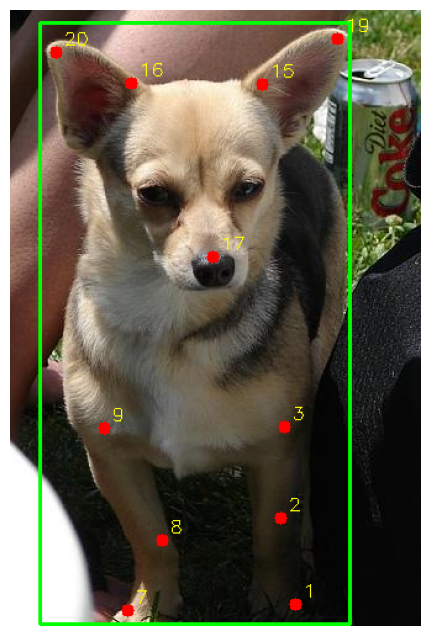

In [11]:
#`v` (visibility): `0` = 미검출, `1` = 가림, `2` = 보임
pts = list(map(float, points[5:]))   # 미리 float 변환

for i in range(0, len(pts), 3):
    px, py, v = pts[i], pts[i+1], pts[i+2]
    if v == 0:
        continue
    cx, cy = int(px * W), int(py * H)
    cv2.circle(img, (cx, cy), 5, (255, 0, 0), -1)
    cv2.putText(img, str(i//3 + 1), (cx + 6, cy - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
pts = list(map(float, points))
pts

[0.0,
 0.45195,
 0.508,
 0.75375,
 0.976,
 0.6952,
 0.965,
 2.0,
 0.66066,
 0.824,
 2.0,
 0.66817,
 0.677,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.28529,
 0.974,
 2.0,
 0.37087,
 0.861,
 2.0,
 0.22823,
 0.678,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.61461,
 0.12067,
 2.0,
 0.2958,
 0.119,
 2.0,
 0.49449,
 0.4,
 2.0,
 0.0,
 0.0,
 0.0,
 0.79878,
 0.04678,
 2.0,
 0.1137,
 0.0682,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

# 모델훈련

In [13]:
from ultralytics import YOLO

# 사전학습 pose 모델 로드 (가장 가벼운 nano)
model = YOLO("yolo11n-pose.pt")

# dog-pose 데이터셋으로 훈련 (에포크 1번)
results = model.train(
    data="dog-pose.yaml",
    epochs=1,
    imgsz=640,
    batch=16,
    project=str(RUNS_DIR),
    name="dog_pose_train",
    exist_ok=True,
)

New https://pypi.org/project/ultralytics/8.4.67 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.66 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dog-pose.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, na

In [14]:
best = YOLO(RUNS_DIR / "dog_pose_train" / "weights" / "best.pt")

img_path = DATASETS_DIR / "dog-pose" / "images" / "train" / "n02085620_10074.jpg"

print(img_path)
print("exists:", img_path.exists())

pred = best(str(img_path))
pred[0].show()

/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/datasets/dog-pose/images/train/n02085620_10074.jpg
exists: True

image 1/1 /mnt/c/Users/sdh08/PycharmProjects/PythonProject1/수업자료/cv/datasets/dog-pose/images/train/n02085620_10074.jpg: 640x448 1 dog, 27.7ms
Speed: 1.2ms preprocess, 27.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)


Try running the update-desktop-database command. If you
don't have this command you should install the
desktop-file-utils package. This package is available from
http://freedesktop.org/wiki/Software/desktop-file-utils/
No applications found for mimetype: image/png
.